In [1]:
dsec_path = "./data/dsec/test/zurich_city_13_a/events/left/events.h5"
v2e_path = "./v2e-output/events_v2e.h5"
framework_path = "./results/zurich_city_13_a_events.h5"

In [2]:
import h5py
import hdf5plugin

import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import os

from framework.utils.dsec.eventslicer import EventSlicer

In [3]:
def inspect(path):
    file = h5py.File(path, "r")
    file_stats = os.stat(path)
    events = file["events"]    
    events_t = events["t"]
    num_events = len(events_t)
    duration = (events_t[-1]-events_t[0])/1e6  
    event_rate = num_events/duration/1000
    print(f"File Size (MB): {file_stats.st_size / (1024*1024):.2f}")
    print(f"Number of Events: {num_events}")
    print(f"Recording Duration: {duration:.2f}s")
    print(f"Event Rate: {event_rate:.2f} KEVs/s")

In [4]:
print("DSEC Events:")
inspect(dsec_path)
print("\nV2E Events:")
inspect(v2e_path)
print("\nFramework Events:")
inspect(framework_path)

DSEC Events:
File Size (MB): 347.41
Number of Events: 152299794
Recording Duration: 18.90s
Event Rate: 8057.76 KEVs/s

V2E Events:
File Size (MB): 651.03
Number of Events: 75832941
Recording Duration: 18.90s
Event Rate: 4012.70 KEVs/s

Framework Events:
File Size (MB): 243.38
Number of Events: 27891565
Recording Duration: 18.85s
Event Rate: 1479.66 KEVs/s


In [5]:
dsec_slicer = EventSlicer(h5py.File(dsec_path, "r"))
v2e_slicer = EventSlicer(h5py.File(v2e_path, "r"))
framework_slicer  = EventSlicer(h5py.File(framework_path, "r"))

In [6]:
def get_stats(event_slicer):
    """
    Calculate statistics for a given event slicer.

    Args:
        event_slicer (EventSlicer): An instance of the EventSlicer class.

    Returns:
        dict: A dictionary containing the following statistics:
            - 'events': Total number of events.
            - 'positive': Number of positive events (polarity = 1).
            - 'negative': Number of negative events (polarity = 0).
            - 'duration_us': Duration of the events in microseconds.
            - 'events_per_second': Average number of events per second.
            - 'min_timestamp': Minimum timestamp of the events.
            - 'max_timestamp': Maximum timestamp of the events.
    """
    start = event_slicer.get_start_time_us()
    end = event_slicer.get_final_time_us()

    # 1 second
    window = 1_000_000

    total = 0
    positive = 0
    negative = 0

    first_t = None
    last_t = None

    for t0 in range(start, end, window):
        t1 = min(t0 + window, end)

        evs = event_slicer.get_events(t0, t1)

        if len(evs["t"]) == 0:
            continue

        if first_t is None:
            first_t = evs["t"][0]

        last_t = evs["t"][-1]

        total += len(evs["t"])
        positive += np.count_nonzero(evs["p"] == 1)
        negative += np.count_nonzero(evs["p"] == 0)
    
    return {
        "events": total,
        "positive": positive,
        "negative": negative,
        "duration_us": last_t - first_t if first_t is not None and last_t is not None else 0,
        "events_per_second": total / ((last_t - first_t) / 1_000_000) if first_t is not None and last_t is not None and (last_t - first_t) > 0 else 0,
        "min_timestamp": first_t,
        "max_timestamp": last_t,
    }

In [7]:
dsec_stats = get_stats(dsec_slicer)
v2e_stats = get_stats(v2e_slicer)
framework_stats = get_stats(framework_slicer)

In [8]:
print("DSEC")
print(f"min_timestamp: {dsec_stats['min_timestamp']}")
print(f"max_timestamp: {dsec_stats['max_timestamp']}")

print("\nV2E")
print(f"min_timestamp: {v2e_stats['min_timestamp']}")
print(f"max_timestamp: {v2e_stats['max_timestamp']}")

print("\nFramework")
print(f"min_timestamp: {framework_stats['min_timestamp']}")
print(f"max_timestamp: {framework_stats['max_timestamp']}")

DSEC
min_timestamp: 41616099917
max_timestamp: 41635000915

V2E
min_timestamp: 41616101702
max_timestamp: 41634997139

Framework
min_timestamp: 41616099917
max_timestamp: 41634899917


In [9]:
metrics_to_plot = ['events', 'positive', 'negative']

df_stats = pd.DataFrame({
    'DSEC': dsec_stats,
    'v2e': v2e_stats,
    'Framework': framework_stats
}, index=metrics_to_plot)

In [10]:
percentage_events = (df_stats.loc['events', 'Framework'] / df_stats.loc['events', 'DSEC']) * 100
print(f"Percentage of events of the framework compared to DSEC: {percentage_events:.2f}%")
percentage_events = (df_stats.loc['events', 'v2e'] / df_stats.loc['events', 'DSEC']) * 100
print(f"Percentage of events of v2e compared to DSEC: {percentage_events:.2f}%")

Percentage of events of the framework compared to DSEC: 18.29%
Percentage of events of v2e compared to DSEC: 49.79%


## Event Count

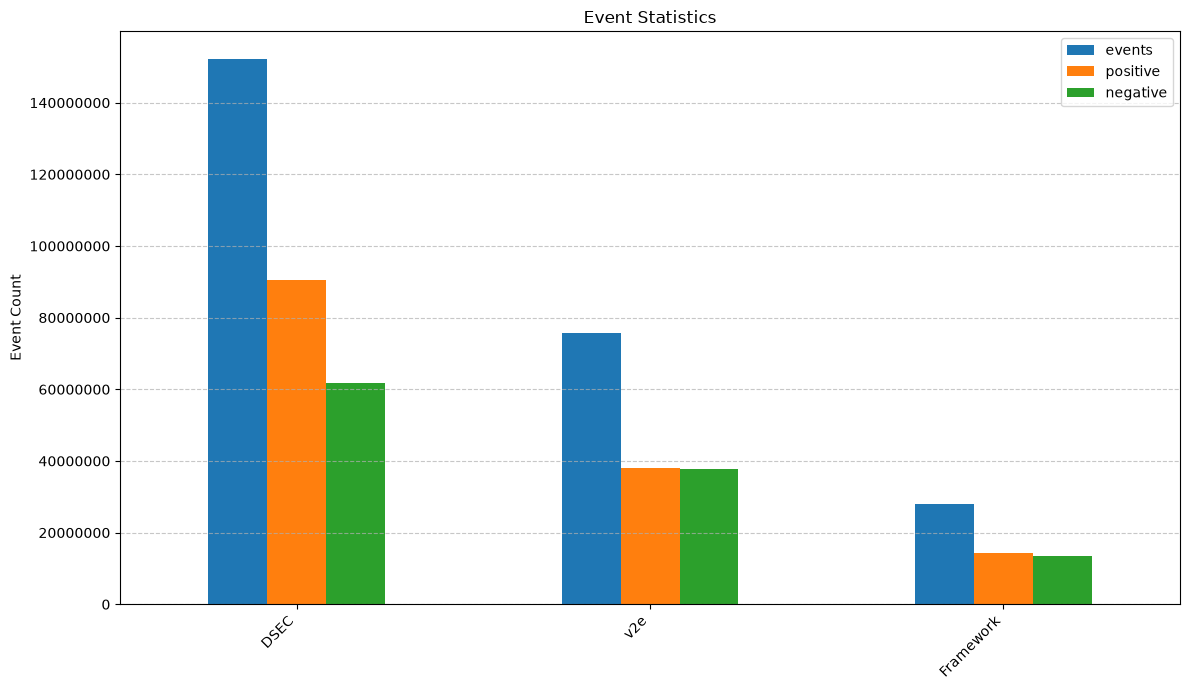

In [67]:
fig, ax = plt.subplots(figsize=(12, 7))
df_stats.T.plot(kind='bar', ax=ax)
ax.set_title('Event Statistics')
ax.set_ylabel('Event Count')
ax.ticklabel_format(style='plain', axis='y')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [68]:
def load_analysis(path):
    """
    Load the analysis results from a JSON file.
    """
    with open(path, "r") as f:
        analysis = json.load(f)
    results = analysis["results"]
    print(f"Valid evaluations : {analysis['valid']}")
    print(f"Skipped           : {analysis['skipped']}")

    return results

In [69]:
framework_analysis_path = "./zurich_city_13_a_summary/analysis.json"
framework_results = load_analysis(framework_analysis_path)

v2e_analysis_path = "./v2e_zurich_city_13_a_summary/analysis.json"
v2e_results = load_analysis(v2e_analysis_path)

Valid evaluations : 377
Skipped           : 0
Valid evaluations : 378
Skipped           : 0


In [70]:
def count_events(subset):
    gt_framework = np.array([r["events"][subset]["gt_count"] for r in framework_results])
    gt_v2e = np.array([r["events"][subset]["gt_count"] for r in v2e_results])
    pred_framework = np.array([r["events"][subset]["pred_count"] for r in framework_results])
    pred_v2e = np.array([r["events"][subset]["pred_count"] for r in v2e_results])

    corr = np.corrcoef(gt_v2e, pred_v2e)[0, 1]
    print(f"{subset.upper()} V2E Correlation: {corr:.3f}")

    corr = np.corrcoef(gt_framework, pred_framework)[0, 1]
    print(f"{subset.upper()} Framework Correlation: {corr:.3f}")

    plt.figure(figsize=(12, 4))
    plt.plot(gt_v2e, label="Ground Truth", linewidth=2)
    plt.plot(pred_v2e, label="Synthetic", linewidth=2)
    plt.plot(pred_framework, label="Framework", linewidth=2)

    plt.title(f"Event Count Comparison ({subset.upper()})")
    plt.xlabel("Frame Index")
    plt.ylabel("Event Count")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

    plots = [
        (axes[0], gt_v2e, pred_v2e, "V2E"),
        (axes[1], gt_framework, pred_framework, "Framework"),
    ]

    for ax, gt, pred, title in plots:
        coef = np.polyfit(gt, pred, 1)
        fit = np.poly1d(coef)
        x = np.linspace(gt.min(), gt.max(), 100)
        time = np.array([r["start_us"] for r in (v2e_results if title == "V2E" else framework_results)], dtype=np.float64) / 1e6
        sc = ax.scatter(gt, pred, c=time, cmap="viridis", s=20)
        ax.plot(x, x, "r--", label="Ideal")
        ax.plot(x, fit(x), "k", lw=2, label="Regression")
        ax.set_title(title)
        ax.set_xlabel("Ground Truth Event Count")
        ax.set_ylabel("Predicted Event Count")
        ax.grid(alpha=0.3)
        ax.legend()

    fig.colorbar(sc, ax=axes.ravel().tolist(), label="Time (s)")
    plt.suptitle(f"Event Count Comparison ({subset.upper()})", y=1.02)
    plt.show()

ALL V2E Correlation: 0.867
ALL Framework Correlation: 0.709


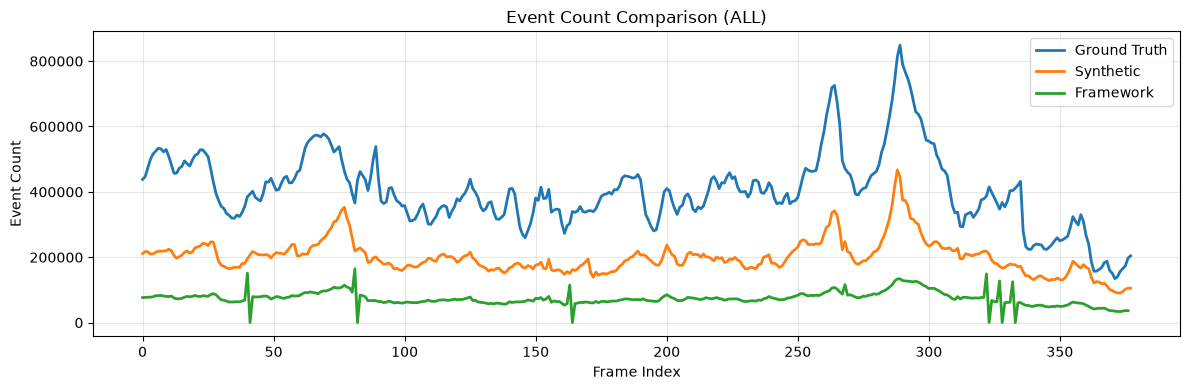

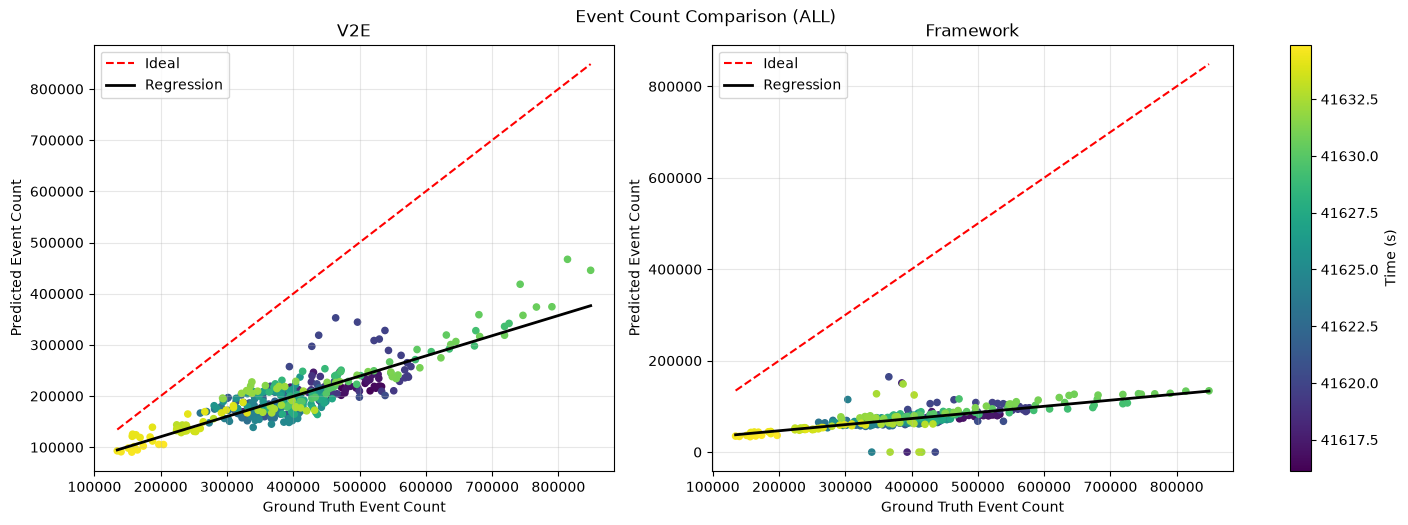

In [71]:
count_events("all")

ON V2E Correlation: 0.817
ON Framework Correlation: 0.685


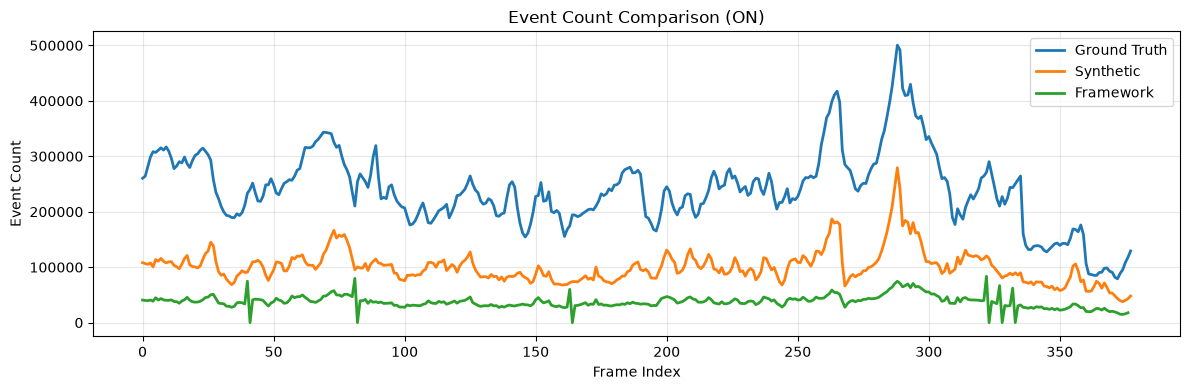

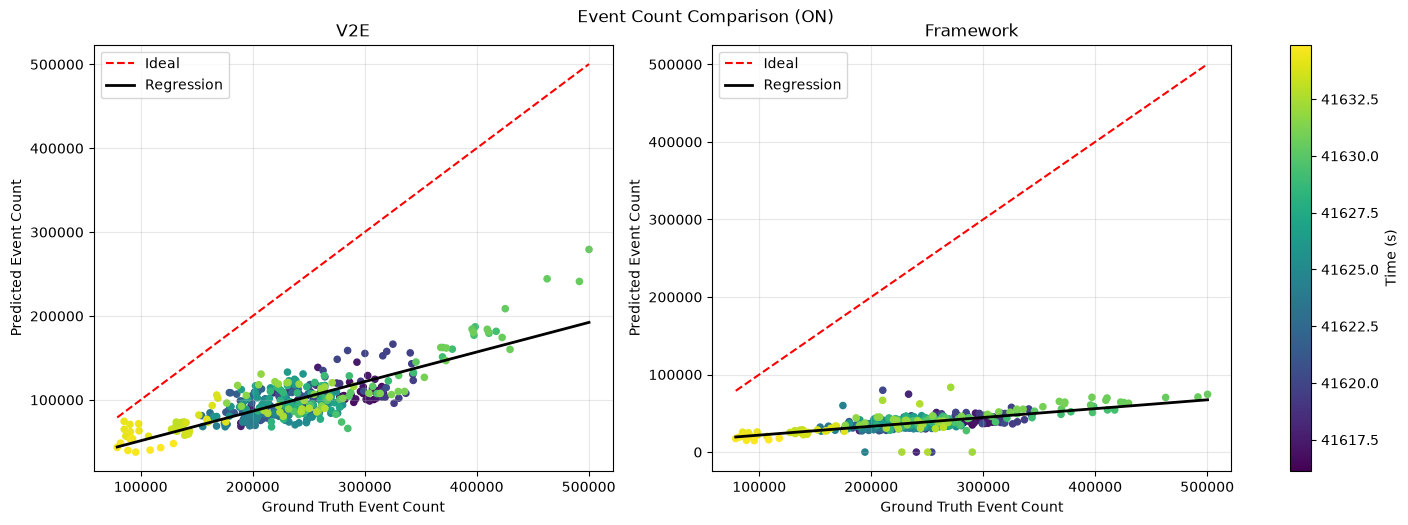

In [72]:
count_events("on")

OFF V2E Correlation: 0.799
OFF Framework Correlation: 0.654


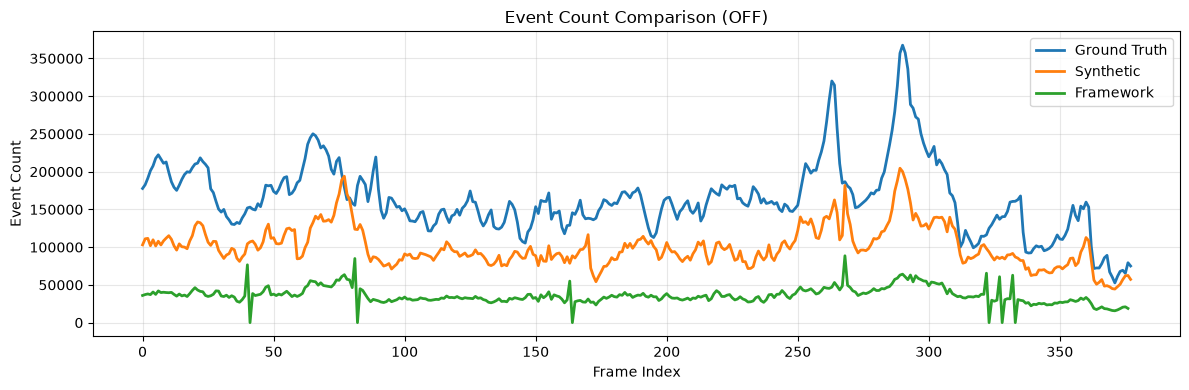

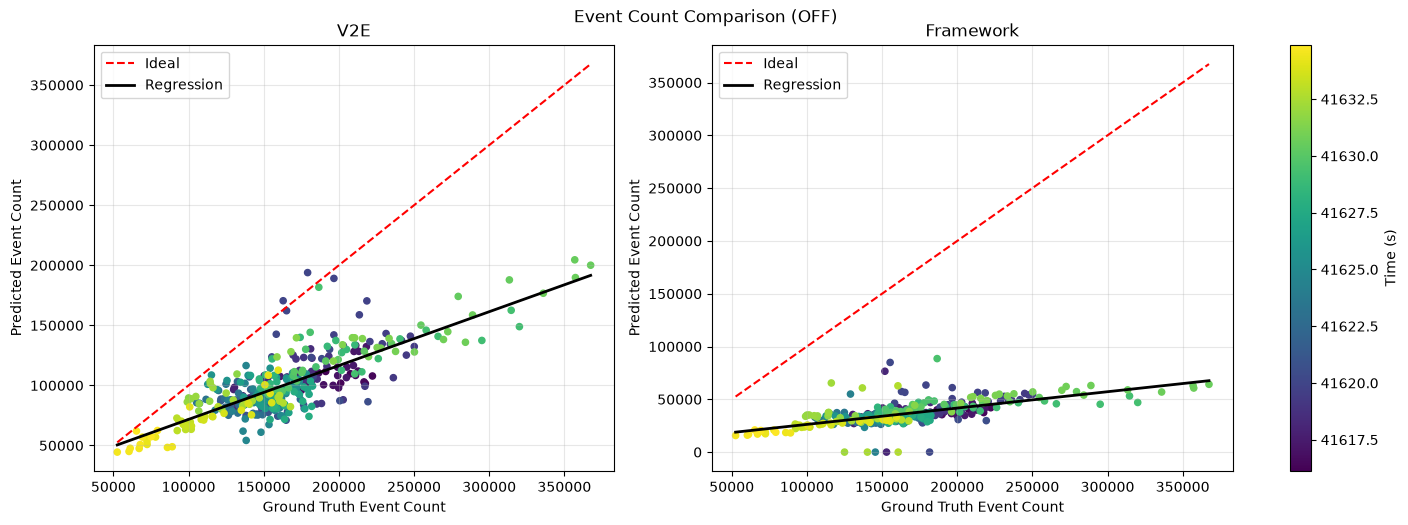

In [73]:
count_events("off")

## Classification Metrics

In [74]:
metrics = ["f1", "precision", "recall", "accuracy"]

for subset in ["all", "on", "off"]:
    data = {
        "V2E": [sum(r["events"][subset][metric] for r in v2e_results) / len(v2e_results) for metric in metrics],
        "Framework": [sum(r["events"][subset][metric] for r in framework_results) / len(framework_results) for metric in metrics],
    }
    df_metrics = pd.DataFrame(data, index=metrics)
    df_metrics.index.name = "Metric"
    print(f"{subset.upper()}")
    print(df_metrics.to_markdown(floatfmt=".4f"))
    print()

ALL
| Metric    |    V2E |   Framework |
|:----------|-------:|------------:|
| f1        | 0.9291 |      0.8675 |
| precision | 0.9127 |      0.9356 |
| recall    | 0.9494 |      0.8093 |
| accuracy  | 0.8720 |      0.7932 |

ON
| Metric    |    V2E |   Framework |
|:----------|-------:|------------:|
| f1        | 0.8851 |      0.8006 |
| precision | 0.8781 |      0.8984 |
| recall    | 0.8981 |      0.7237 |
| accuracy  | 0.8051 |      0.7094 |

OFF
| Metric    |    V2E |   Framework |
|:----------|-------:|------------:|
| f1        | 0.8938 |      0.8110 |
| precision | 0.9286 |      0.9304 |
| recall    | 0.8640 |      0.7205 |
| accuracy  | 0.8219 |      0.7185 |

